<a href="https://colab.research.google.com/github/daaastis/fundamentals-of-data-mining/blob/main/%D0%9F%D0%BE%D0%B8%D1%81%D0%BA_%D0%B0%D1%81%D1%81%D0%BE%D1%86%D0%B8%D0%B0%D1%82%D0%B8%D0%B2%D0%BD%D1%8B%D1%85_%D0%BF%D1%80%D0%B0%D0%B2%D0%B8%D0%BB.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

 ЭТАП 1: ЗАГРУЗКА И ПОДГОТОВКА ДАННЫХ ИЗ baskets.csv 
[+] Файл успешно прочитан с кодировкой: 'cp1251'
[Успешно] Всего обработано транзакций из baskets.csv: 7501

 ЭТАП 2: ВЫПОЛНЕНИЕ ЭКСПЕРИМЕНТОВ (МИН. ПОДДЕРЖКА = 1%) 
╒═══════════════════════════╤══════════════════╤════════════════════════════╕
│ Порог Достоверности (%)   │   Найдено правил │   Время поиска правил (мс) │
╞═══════════════════════════╪══════════════════╪════════════════════════════╡
│ 20%                       │              164 │                      0.959 │
├───────────────────────────┼──────────────────┼────────────────────────────┤
│ 25%                       │               99 │                      0.825 │
├───────────────────────────┼──────────────────┼────────────────────────────┤
│ 30%                       │               65 │                      0.769 │
├───────────────────────────┼──────────────────┼────────────────────────────┤
│ 35%                       │               34 │                      0.497 │


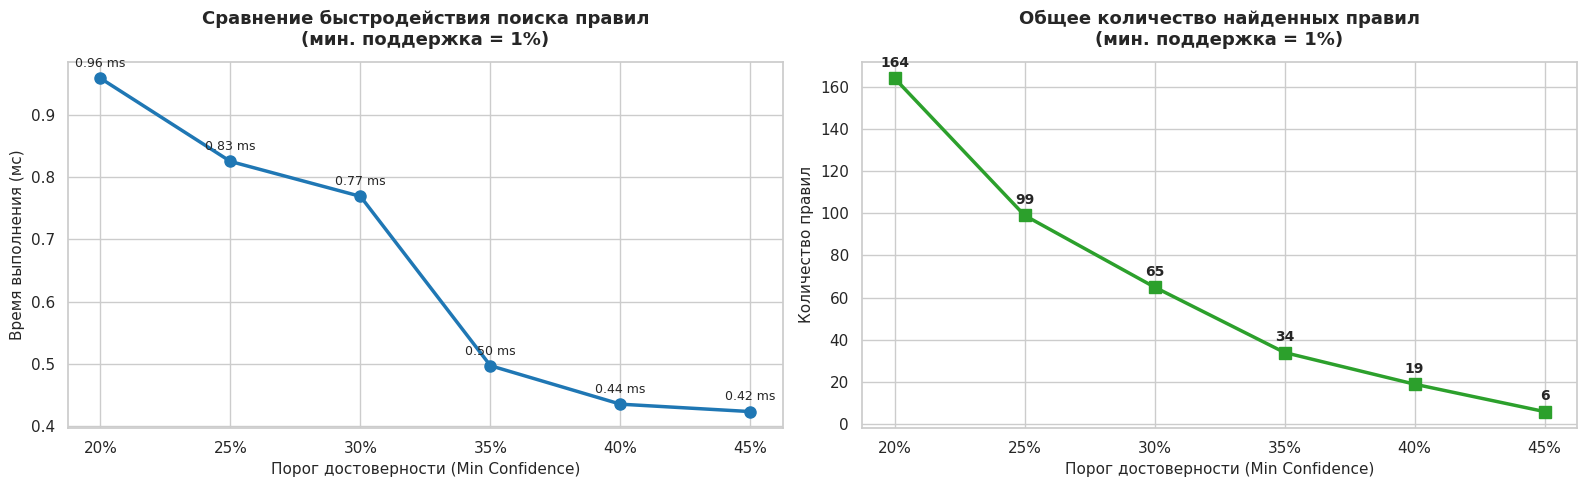


 ЭТАП 4: РЕЗУЛЬТИРУЮЩИЕ ПРАВИЛА В УДОБОЧИТАЕМОМ ВИДЕ (ДЛИНА <= 7) 
Всего найденных правил (длина <= 7, support >= 1%, conf >= 20%): 164

ТОП-20 НАИБОЛЕЕ ДОСТОВЕРНЫХ ПРАВИЛ:
╒═════════════════════════════════════════════════════╤═══════════════════════╤══════════════════════════════╤════════════════════╕
│ Ассоциативное правило (Антецедент → Консеквент)     │ Поддержка (Support)   │ Достоверность (Confidence)   │   Суммарный размер │
╞═════════════════════════════════════════════════════╪═══════════════════════╪══════════════════════════════╪════════════════════╡
│ {говяжий фарш, яйца} → {минеральная вода}           │ 1.01%                 │ 50.67%                       │                  3 │
├─────────────────────────────────────────────────────┼───────────────────────┼──────────────────────────────┼────────────────────┤
│ {говяжий фарш, молоко} → {минеральная вода}         │ 1.11%                 │ 50.30%                       │                  3 │
├─────────────────────────────────

In [8]:
import os
import time
import itertools
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

!pip install tabulate -q
from tabulate import tabulate

# =================================================================
# 1. ЗАГРУЗКА ДАННЫХ ИЗ baskets.csv
# =================================================================
print("=" * 75)
print(" ЭТАП 1: ЗАГРУЗКА И ПОДГОТОВКА ДАННЫХ ИЗ baskets.csv ")
print("=" * 75)

dataset_filename = 'baskets.csv'

def load_baskets_dataset(filename):
    if not os.path.exists(filename):
        return None
    encodings = ['cp1251', 'utf-8', 'windows-1251', 'latin1']
    for enc in encodings:
        try:
            df = pd.read_csv(filename, header=None, encoding=enc, sep=None, engine='python')
            if df.shape[1] >= 1:
                print(f"[+] Файл успешно прочитан с кодировкой: '{enc}'")
                return df
        except Exception:
            continue
    return None

df_raw = load_baskets_dataset(dataset_filename)

if df_raw is None:
    raise FileNotFoundError("Загрузите файл baskets.csv в боковую панель Colab!")

transactions = []
for _, row in df_raw.iterrows():
    basket = list(row.dropna().astype(str).str.strip())
    basket = [item for item in basket if item and item.lower() != 'nan']
    if basket:
        transactions.append(basket)

print(f"[Успешно] Всего обработано транзакций из baskets.csv: {len(transactions)}\n")


# =================================================================
# 2. АЛГОРИТМ APRIORI И ГЕНЕРАЦИЯ ПРАВИЛ
# =================================================================
class AprioriWithRules:
    def __init__(self, min_support=0.01, min_confidence=0.10, sort_by='confidence_desc'):
        self.min_support = min_support
        self.min_confidence = min_confidence
        self.sort_by = sort_by
        self.frequent_itemsets_counts = {}
        self.num_transactions = 0

    def fit_itemsets(self, transactions):
        self.num_transactions = len(transactions)
        min_count = self.min_support * self.num_transactions

        item_counts = {}
        for transaction in transactions:
            for item in set(transaction):
                item_counts[item] = item_counts.get(item, 0) + 1

        current_l = {frozenset([item]): count for item, count in item_counts.items() if count >= min_count}
        frequent_itemsets = dict(current_l)

        k = 2
        while current_l:
            items = list(current_l.keys())
            candidates = set()
            for i in range(len(items)):
                for j in range(i + 1, len(items)):
                    union_set = items[i] | items[j]
                    if len(union_set) == k:
                        subsets = [union_set - frozenset([elem]) for elem in union_set]
                        if all(sub in current_l for sub in subsets):
                            candidates.add(union_set)

            candidate_counts = {cand: 0 for cand in candidates}
            for transaction in transactions:
                trans_set = set(transaction)
                for cand in candidates:
                    if cand.issubset(trans_set):
                        candidate_counts[cand] += 1

            current_l = {cand: count for cand, count in candidate_counts.items() if count >= min_count}
            frequent_itemsets.update(current_l)
            k += 1

        self.frequent_itemsets_counts = frequent_itemsets
        return frequent_itemsets

    def generate_rules(self, frequent_itemsets=None):
        if frequent_itemsets is None:
            frequent_itemsets = self.frequent_itemsets_counts

        rules = []
        for itemset, itemset_count in frequent_itemsets.items():
            if len(itemset) < 2:
                continue

            support_itemset = itemset_count / self.num_transactions
            items = list(itemset)

            for r in range(1, len(items)):
                for ant_tuple in itertools.combinations(items, r):
                    antecedent = frozenset(ant_tuple)
                    consequent = itemset - antecedent

                    antecedent_count = self.frequent_itemsets_counts.get(antecedent, 0)
                    if antecedent_count == 0:
                        continue

                    confidence = itemset_count / antecedent_count

                    if confidence >= self.min_confidence:
                        rules.append({
                            'antecedent': sorted(list(antecedent)),
                            'consequent': sorted(list(consequent)),
                            'support': support_itemset,
                            'confidence': confidence,
                            'total_length': len(itemset)
                        })

        if self.sort_by == 'confidence_desc':
            rules.sort(key=lambda x: (x['confidence'], x['support']), reverse=True)
        elif self.sort_by == 'support_desc':
            rules.sort(key=lambda x: (x['support'], x['confidence']), reverse=True)
        elif self.sort_by == 'lexicographical':
            rules.sort(key=lambda x: (str(x['antecedent']), str(x['consequent'])))

        return rules


# =================================================================
# 3. ЭКСПЕРИМЕНТЫ
# =================================================================
# Ставим порог поддержки 1% (0.01), чтобы в baskets.csv сформировались
# частые наборы из нескольких товаров для генерации правил
FIXED_SUPPORT = 0.01
conf_thresholds = [0.20, 0.25, 0.30, 0.35, 0.40, 0.45]  # Рабочие пороги достоверности для транзакций супермаркета

print("=" * 75)
print(f" ЭТАП 2: ВЫПОЛНЕНИЕ ЭКСПЕРИМЕНТОВ (МИН. ПОДДЕРЖКА = {int(FIXED_SUPPORT*100)}%) ")
print("=" * 75)

model = AprioriWithRules(min_support=FIXED_SUPPORT, sort_by='confidence_desc')

# Поиск частых наборов
t0 = time.time()
frequent_itemsets = model.fit_itemsets(transactions)

exec_times_rules = []
rules_counts = []
rules_by_conf = {}

for conf in conf_thresholds:
    start_t = time.time()
    model.min_confidence = conf
    found_rules = model.generate_rules(frequent_itemsets)
    elapsed_ms = (time.time() - start_t) * 1000

    exec_times_rules.append(elapsed_ms)
    rules_counts.append(len(found_rules))
    rules_by_conf[conf] = found_rules

exp_summary = pd.DataFrame({
    'Порог Достоверности (%)': [f"{int(c*100)}%" for c in conf_thresholds],
    'Найдено правил': rules_counts,
    'Время поиска правил (мс)': [f"{t:.3f}" for t in exec_times_rules]
})

print(tabulate(exp_summary, headers='keys', tablefmt='fancy_grid', showindex=False))
print()

# =================================================================
# 3. ВИЗУАЛИЗАЦИЯ (ПОСТРОЕНИЕ ЛИНЕЙНЫХ ГРАФИКОВ)
# =================================================================
print("=" * 75)
print(" ЭТАП 3: ВИЗУАЛИЗАЦИЯ (ПОСТРОЕНИЕ ГРАФИКОВ) ")
print("=" * 75)

sns.set_theme(style="whitegrid")
plt.rcParams.update({'font.size': 11})

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# График 1: Быстродействие
axes[0].plot([f"{int(c*100)}%" for c in conf_thresholds], exec_times_rules,
            marker='o', color='#1f77b4', linewidth=2.5, markersize=8)
axes[0].set_title(f"Сравнение быстродействия поиска правил\n(мин. поддержка = {int(FIXED_SUPPORT*100)}%)",
                  fontsize=13, pad=12, fontweight='bold')
axes[0].set_xlabel("Порог достоверности (Min Confidence)", fontsize=11)
axes[0].set_ylabel("Время выполнения (мс)", fontsize=11)

for x, y in zip([f"{int(c*100)}%" for c in conf_thresholds], exec_times_rules):
    axes[0].annotate(f"{y:.2f} ms", (x, y), textcoords="offset points", xytext=(0, 8), ha='center', fontsize=9)

# График 2: Общее количество найденных правил (теперь линейный график)
axes[1].plot([f"{int(c*100)}%" for c in conf_thresholds], rules_counts,
            marker='s', color='#2ca02c', linewidth=2.5, markersize=8)
axes[1].set_title(f"Общее количество найденных правил\n(мин. поддержка = {int(FIXED_SUPPORT*100)}%)",
                  fontsize=13, pad=12, fontweight='bold')
axes[1].set_xlabel("Порог достоверности (Min Confidence)", fontsize=11)
axes[1].set_ylabel("Количество правил", fontsize=11)

for x, y in zip([f"{int(c*100)}%" for c in conf_thresholds], rules_counts):
    axes[1].annotate(f"{y}", (x, y), textcoords="offset points", xytext=(0, 8), ha='center', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()


# =================================================================
# 5. СПИСОК НАЙДЕННЫХ ПРАВИЛ
# =================================================================
print("\n" + "=" * 75)
print(" ЭТАП 4: РЕЗУЛЬТИРУЮЩИЕ ПРАВИЛА В УДОБОЧИТАЕМОМ ВИДЕ (ДЛИНА <= 7) ")
print("=" * 75)

# Берем правила при начальном пороге достоверности (20%)
base_conf = conf_thresholds[0]
rules_filtered = [r for r in rules_by_conf[base_conf] if r['total_length'] <= 7]

formatted_rules = []
for r in rules_filtered:
    ant_str = "{" + ", ".join(r['antecedent']) + "}"
    cons_str = "{" + ", ".join(r['consequent']) + "}"
    rule_fmt = f"{ant_str} → {cons_str}"
    formatted_rules.append({
        'Ассоциативное правило (Антецедент → Консеквент)': rule_fmt,
        'Поддержка (Support)': f"{r['support']*100:.2f}%",
        'Достоверность (Confidence)': f"{r['confidence']*100:.2f}%",
        'Суммарный размер': r['total_length']
    })

df_rules = pd.DataFrame(formatted_rules)

print(f"Всего найденных правил (длина <= 7, support >= {int(FIXED_SUPPORT*100)}%, conf >= {int(base_conf*100)}%): {len(df_rules)}\n")

if len(df_rules) > 0:
    print("ТОП-20 НАИБОЛЕЕ ДОСТОВЕРНЫХ ПРАВИЛ:")
    print(tabulate(df_rules.head(20), headers='keys', tablefmt='fancy_grid', showindex=False))